In [159]:
%load_ext autoreload
%autoreload 2

import sys
import os
import typing as tp
import math
from importlib import reload

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Union, Tuple, List
from mars import spin_model, spectra_manager, mesher, constants
import mars

from sample_creators_local import (
                             create_5_electrons_sample, create_2_electrons_2_nuclei_sample,
                             create_1_high_spin_electron_1_nuclei_sample, create_2_middle_spin_sample,
                             create_3_middle_spin_sample
                             )

from saving_benchmarks import save_benchmark_results, load_benchmark_results

from bencmarking import benchmark_several_configurations, compare_benchmarks, plot_benchmark_comparison, time_spectrum_calculation_full_pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [160]:
import matplotlib.pyplot as plt
dtype = torch.float64
device = torch.device("cpu")

In [240]:
def create_bug_spin_system_spin_sample(
        mesh: tp.Optional[tp.Union[mesher.BaseMesh, tp.Tuple[int, int]]] = None,
        device: torch.device = torch.device("cpu"),
        dtype: torch.dtype = torch.float64
) -> spin_model.MultiOrientedSample:
    """
    Create a sample with 3 Cobalt spins

    Models Mn(II) ion system with zero-field splitting and hyperfine coupling.
    Hilbert space dimension = 36 states. Computationally intensive due to
    large matrix diagonalization requirements.

    Parameters
    ----------
    mesh : BaseMesh or tuple of (int, int), optional
        Orientation mesh. Coarse mesh recommended for initial timing tests.
    device : torch.device, optional
        Computation device. GPU essential for reasonable performance.
    dtype : torch.dtype, optional
        Floating point precision. float64 required for ZFS accuracy.

    Returns
    -------
    MultiOrientedSample

    """
    g_tensor = spin_model.Interaction((2.00, 2.01, 2.02), device=device, dtype=dtype)

    zfs = spin_model.DEInteraction(
        [constants.unit_converter(-100.0, "cm-1_to_Hz"), constants.unit_converter(-10.0, "cm-1_to_Hz")],
        device=device,
        dtype=dtype
    )

    dipolar = spin_model.DEInteraction(
        [0, 0],
        device=device,
        dtype=dtype
    )

    exchange = spin_model.Interaction(
        constants.unit_converter(0.01, "cm-1_to_Hz"),
        device=device,
        dtype=dtype
    )

    spin_sys = spin_model.SpinSystem(
        electrons=[3/2, 1/2, 3/2],
        g_tensors=[g_tensor, g_tensor, g_tensor],
        electron_electron=[(0, 0, zfs), (2, 2, zfs), (0, 1, dipolar + exchange), (1, 2, dipolar + exchange)],
        device=device,
        dtype=dtype
    )

    sample = spin_model.MultiOrientedSample(
        base_spin_system=spin_sys,
        gauss=0.0015,
        lorentz=0.0015,
        mesh=mesh,
        device=device,
        dtype=dtype
    )

    return sample

In [244]:
mesh = mars.mesher.DelaunayMesh(initial_grid_frequency=20, interpolation_grid_frequency=100, interpolator="rbf", dtype=dtype, interpolate=False)

sample_two_spins = create_bug_spin_system_spin_sample(mesh=mesh, device="cpu", dtype=dtype)

freq = 35.0 * 1e9,
field_range = (1.19, 1.29)
n_points = 1000
temperature = 298.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-2, res_field_r_tol=1e-4, integration_gaussian_cutoff=3.5)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_two_spins,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)
    
out = creator(sample=sample_two_spins, fields=fields)

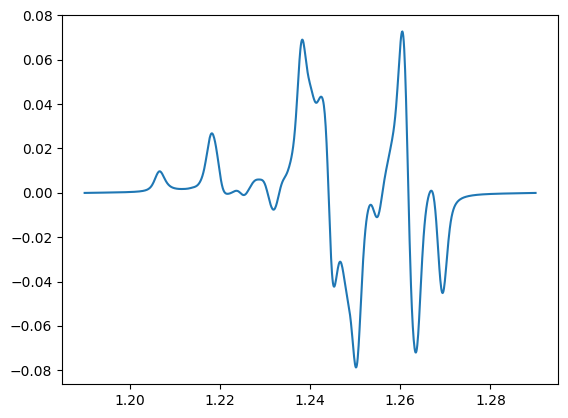

In [245]:
plt.plot(fields, out)

In [246]:
mars.save("easyspin/out_bug.mat", sample=sample_two_spins, spectra_creator=creator, field=fields, format_type="easyspin")
data_frame = pd.DataFrame({"field": fields, "spec": out})

data_frame.to_csv(f"easyspin/spectrum_bug.csv", header=False, index=False)